## Cross-validation base/full model comparison

Set `RESULT_FILE` to any JSON result beneath `scripts/output` (or to an absolute path). The notebook extracts the best epoch and test-set energy/force MAEs for however many folds are present, prints the fold-level and summary data, and plots the mean with sample standard deviation error bars.

Loaded data from: /home/yutong/X-MACE-sampling/scripts/output/run_5/result.json
Fold counts: {'Base model': 5, 'Full model': 5}

Fold-level data:
     model    fold  best_epoch  energy_mae_ev  force_mae_ev_per_ang
Base model model_1          94       0.062199              0.102879
Base model model_2         172       0.053873              0.078630
Base model model_3          83       0.078716              0.105692
Base model model_4          98       0.068117              0.101611
Base model model_5          79       0.061028              0.118899
Full model model_1          95       0.070583              0.123894
Full model model_2          40       0.077190              0.179322
Full model model_3          64       0.123024              0.161210
Full model model_4          84       0.083550              0.127108
Full model model_5         119       0.069767              0.120178

Mean and sample standard deviation across folds:
           best_epoch            energy_mae_ev          

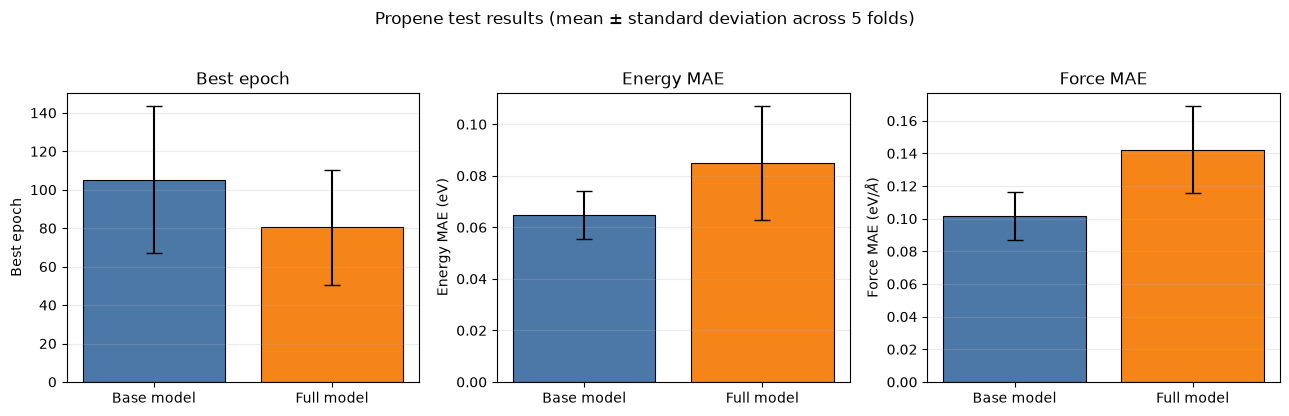

In [16]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Path relative to scripts/output, or an absolute path to a result JSON file.
RESULT_FILE = Path("run_5/result.json")

# This works whether the kernel starts in the repository root or notebooks/.
if RESULT_FILE.is_absolute():
    result_candidates = [RESULT_FILE]
else:
    result_candidates = [
        Path("scripts/output") / RESULT_FILE,
        Path("../scripts/output") / RESULT_FILE,
    ]
result_path = next((path.resolve() for path in result_candidates if path.is_file()), None)
if result_path is None:
    raise FileNotFoundError(
        f"Could not find {RESULT_FILE} beneath scripts/output from the current directory."
    )

with result_path.open() as file:
    result = json.load(file)

training = result["cross_validation_training"]
model_groups = {
    "Base model": "base_models",
    "Full model": "full_high_fidelity_models",
}

def natural_sort_key(value):
    return [int(part) if part.isdigit() else part for part in re.split(r"(\d+)", value)]


records = []
for model_label, group_key in model_groups.items():
    folds = training[group_key]["folds"]
    if not folds:
        raise ValueError(f"No folds found for {model_label}")

    for fold_key in sorted(folds, key=natural_sort_key):
        metrics = folds[fold_key]["metrics"]
        records.append(
            {
                "model": model_label,
                "fold": fold_key,
                "best_epoch": metrics["best_epoch"],
                "energy_mae_ev": metrics["energy_mae_ev"],
                "force_mae_ev_per_ang": metrics["force_mae_ev_per_ang"],
            }
        )

fold_data = pd.DataFrame(records)
metric_columns = ["best_epoch", "energy_mae_ev", "force_mae_ev_per_ang"]
grouped = fold_data.groupby("model", sort=False)[metric_columns]
summary = grouped.agg(["mean", "std"])
fold_counts = fold_data.groupby("model", sort=False).size()

print(f"Loaded data from: {result_path}")
print("Fold counts:", fold_counts.to_dict())
print("\nFold-level data:")
print(fold_data.to_string(index=False))
print("\nMean and sample standard deviation across folds:")
print(summary.to_string())

plot_specs = [
    ("best_epoch", "Best epoch", "Best epoch"),
    ("energy_mae_ev", "Energy MAE", "Energy MAE (eV)"),
    ("force_mae_ev_per_ang", "Force MAE", r"Force MAE (eV/$\AA$)"),
]
model_order = list(model_groups)
colors = ["#4C78A8", "#F58518"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (column, title, ylabel) in zip(axes, plot_specs):
    means = summary.loc[model_order, (column, "mean")].to_numpy()
    # A single fold has no sample standard deviation, so display a zero error bar.
    stds = summary.loc[model_order, (column, "std")].fillna(0).to_numpy()
    x = np.arange(len(model_order))

    ax.bar(
        x,
        means,
        yerr=stds,
        capsize=6,
        color=colors,
        edgecolor="black",
        linewidth=0.8,
    )
    ax.set_xticks(x, model_order)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)

fold_description = ", ".join(
    f"{model}: {count} fold{'s' if count != 1 else ''}"
    for model, count in fold_counts.items()
)
fig.suptitle(
    f"Propene test results (mean ± standard deviation across 5 folds)\n"
)
fig.tight_layout()
plt.show()


# Butene

     model  fold  best_epoch  energy_mae_ev  force_mae_ev_per_ang
Base model     1         148       0.053135              0.061814
Base model     2          42       0.080003              0.099636
Base model     3         104       0.090429              0.068583
Base model     4          66       0.068785              0.075576
Base model     5          78       0.095689              0.079005
Full model     1          10       1.217875              0.709762
Full model     2           2       1.440978              0.852747
Full model     3           2       1.841792              1.256802
Full model     4          16       0.615367              0.556463
Full model     5          12       0.913333              0.760313

Mean and standard deviation across folds:
           best_epoch            energy_mae_ev           force_mae_ev_per_ang          
                 mean        std          mean       std                 mean       std
model                                                  

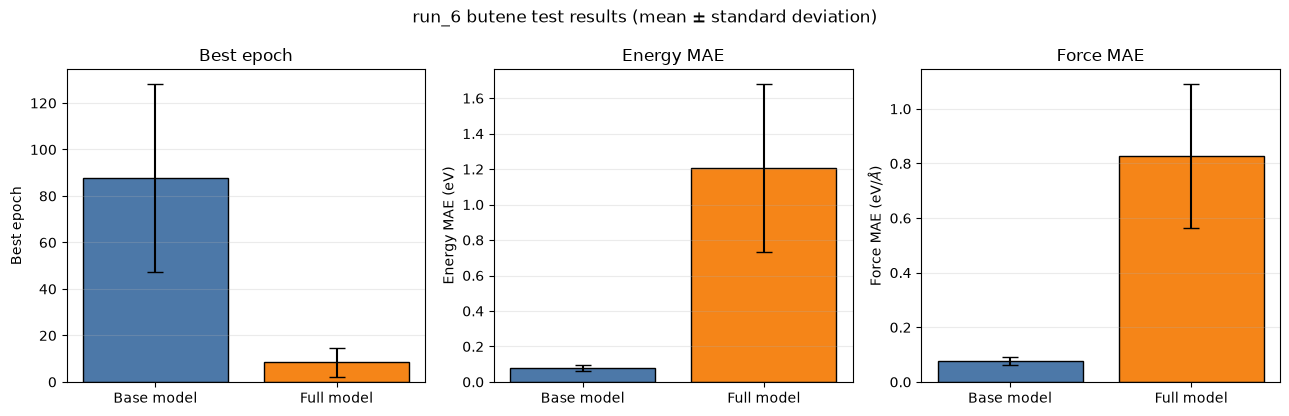

In [ ]:
import gc
import json
from pathlib import Path

import ase.io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython import get_ipython
from scripts.tester import _evaluate, _import_project_modules, _load_model

get_ipython().run_line_magic("matplotlib", "inline")

run_dir = Path("/home/yutong/X-MACE-sampling/scripts/output/run_6")
base_xyz = Path("/home/yutong/X-MACE-sampling/data/A03_butene_offgrid_128_sobol_2e2o.xyz")
full_xyz = Path("/home/yutong/X-MACE-sampling/data/A03_butene_offgrid_SA3-NEVPT2-22_molcas.xyz")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

result = json.loads((run_dir / "result.json").read_text())
config = result["config"]
modules = _import_project_modules()
Builder, Tester = modules[1], modules[2]
builder = Builder(
    cutoff=config.get("r_max", 5.0),
    energy_key=config.get("energy_key", "REF_energy"),
    forces_key=config.get("forces_key", "REF_forces"),
)
batch_size = config.get("batch_size", 64)
loaders = {
    "Base model": builder.load(ase.io.read(base_xyz, index=":"), batch_size=batch_size, shuffle=False),
    "Full model": builder.load(ase.io.read(full_xyz, index=":"), batch_size=batch_size, shuffle=False),
}
model_groups = {
    "Base model": ("base_model_fold_*.pt", "base_models"),
    "Full model": ("full_model_fold_*.pt", "full_high_fidelity_models"),
}

rows = []
for label, (pattern, group) in model_groups.items():
    for path in sorted(run_dir.glob(pattern), key=lambda p: int(p.stem.rsplit("_", 1)[1])):
        fold = int(path.stem.rsplit("_", 1)[1])
        model = _load_model(path, device)
        metrics = _evaluate(model, loaders[label], Tester(device=device))
        rows.append({
            "model": label,
            "fold": fold,
            "best_epoch": result["cross_validation_training"][group]["folds"][f"model_{fold}"]["metrics"]["best_epoch"],
            **metrics,
        })
        del model
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()


In [ ]:

run_6_data = pd.DataFrame(rows)
metrics = ["best_epoch", "energy_mae_ev", "force_mae_ev_per_ang"]
run_6_summary = run_6_data.groupby("model", sort=False)[metrics].agg(["mean", "std"])
print(run_6_data.to_string(index=False))
print("\nMean and standard deviation across folds:")
print(run_6_summary.to_string())

specs = [
    ("best_epoch", "Best epoch", "Best epoch"),
    ("energy_mae_ev", "Energy MAE", "Energy MAE (eV)"),
    ("force_mae_ev_per_ang", "Force MAE", r"Force MAE (eV/$\AA$)"),
]
order = list(model_groups)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (metric, title, ylabel) in zip(axes, specs):
    means = run_6_summary.loc[order, (metric, "mean")]
    stds = run_6_summary.loc[order, (metric, "std")].fillna(0)
    bars = ax.bar(order, means, yerr=stds, capsize=6, color=["#4C78A8", "#F58518"], edgecolor="black")
    #ax.bar_label(bars, fmt="%.4g", padding=3)
    ax.set(title=title, ylabel=ylabel)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Butene test results (mean ± standard deviation across 5 folds)")
fig.tight_layout()
plt.show()


# Ethene

     model  fold  best_epoch  energy_mae_ev  force_mae_ev_per_ang
Base model     1          34       0.084322              0.112748
Base model     2          36       0.101542              0.121871
Base model     3          46       0.093913              0.108255
Base model     4         120       0.072913              0.085604
Base model     5          32       0.097920              0.099848
Full model     1          28       0.115218              0.097846
Full model     2          33       0.095219              0.111691
Full model     3          32       0.132136              0.096106
Full model     4          33       0.110004              0.103013
Full model     5          33       0.078667              0.096620

Mean and standard deviation across folds:
           best_epoch            energy_mae_ev           force_mae_ev_per_ang          
                 mean        std          mean       std                 mean       std
model                                                  

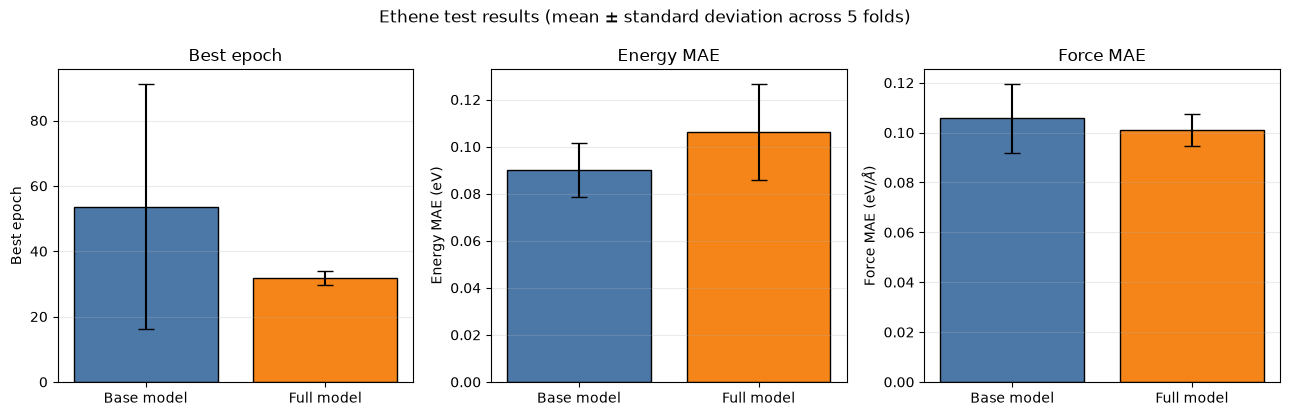

In [ ]:
import gc
import json
from pathlib import Path

import ase.io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython import get_ipython
from scripts.tester import _evaluate, _import_project_modules, _load_model

get_ipython().run_line_magic("matplotlib", "inline")

run_dir = Path("/home/yutong/X-MACE-sampling/scripts/output/run_4")
base_xyz = Path("/home/yutong/X-MACE-sampling/data/A01_ethene_offgrid_128_sobol_2e2o.xyz")
full_xyz = Path("/home/yutong/X-MACE-sampling/data/A01_ethene_offgrid_SA3-NEVPT2-22_molcas.xyz")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

result = json.loads((run_dir / "result.json").read_text())
config = result["config"]
modules = _import_project_modules()
Builder, Tester = modules[1], modules[2]
builder = Builder(
    cutoff=config.get("r_max", 5.0),
    energy_key=config.get("energy_key", "REF_energy"),
    forces_key=config.get("forces_key", "REF_forces"),
)
batch_size = config.get("batch_size", 64)
loaders = {
    "Base model": builder.load(ase.io.read(base_xyz, index=":"), batch_size=batch_size, shuffle=False),
    "Full model": builder.load(ase.io.read(full_xyz, index=":"), batch_size=batch_size, shuffle=False),
}
model_groups = {
    "Base model": ("base_model_fold_*.pt", "base_models"),
    "Full model": ("full_model_fold_*.pt", "full_high_fidelity_models"),
}

rows = []
for label, (pattern, group) in model_groups.items():
    for path in sorted(run_dir.glob(pattern), key=lambda p: int(p.stem.rsplit("_", 1)[1])):
        fold = int(path.stem.rsplit("_", 1)[1])
        model = _load_model(path, device)
        metrics = _evaluate(model, loaders[label], Tester(device=device))
        rows.append({
            "model": label,
            "fold": fold,
            "best_epoch": result["cross_validation_training"][group]["folds"][f"model_{fold}"]["metrics"]["best_epoch"],
            **metrics,
        })
        del model
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()


In [ ]:

run_4_data = pd.DataFrame(rows)
metrics = ["best_epoch", "energy_mae_ev", "force_mae_ev_per_ang"]
run_4_summary = run_4_data.groupby("model", sort=False)[metrics].agg(["mean", "std"])
print(run_4_data.to_string(index=False))
print("\nMean and standard deviation across folds:")
print(run_4_summary.to_string())

specs = [
    ("best_epoch", "Best epoch", "Best epoch"),
    ("energy_mae_ev", "Energy MAE", "Energy MAE (eV)"),
    ("force_mae_ev_per_ang", "Force MAE", r"Force MAE (eV/$\AA$)"),
]
order = list(model_groups)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (metric, title, ylabel) in zip(axes, specs):
    means = run_4_summary.loc[order, (metric, "mean")]
    stds = run_4_summary.loc[order, (metric, "std")].fillna(0)
    bars = ax.bar(order, means, yerr=stds, capsize=6, color=["#4C78A8", "#F58518"], edgecolor="black")
    #ax.bar_label(bars, fmt="%.4g", padding=3)
    ax.set(title=title, ylabel=ylabel)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Ethene test results (mean ± standard deviation across 5 folds)")
fig.tight_layout()
plt.show()